In [26]:
import os
import time
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    f1_score,
    recall_score,
    precision_score
)


In [27]:
# Load training data set
df_train = pd.read_csv("KDD_Train_Set.csv")   # df -> our data frame of training data set
df_test = pd.read_csv("KDD_Test_Set.csv")   # df -> our data frame of testing data set


combined_df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

### Recognizing data set

In [28]:
headers = list(combined_df.columns.values) # Return No. features(columns) names(values)
print(f"Headers: -\n{headers}\n")
print(f"Number of features: {len(headers) - 1}") # -1 As label column is not execluded
print(combined_df.head())    # Print 1st 5 elements in the given data
print(len(combined_df))      # Print the number of rows
print("Training data set description: -\n\n")
combined_df.info()
combined_df.describe().T   # Transpose it to make it easier to be read

Headers: -
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']

Number of features: 41
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0

,count,mean,std,min,25%,50%,75%,max
duration,148516.0,276.781168,2.460691e+03,0.0,0.00,0.00,0.00,5.771500e+04
src_bytes,148516.0,40228.220158,5.409630e+06,0.0,0.00,44.00,278.00,1.379964e+09
dst_bytes,148516.0,17088.968657,3.703537e+06,0.0,0.00,0.00,571.00,1.309937e+09
land,148516.0,0.000215,1.467719e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,148516.0,0.020523,2.400699e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,148516.0,0.000202,1.941714e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,148516.0,0.189380,2.013167e+00,0.0,0.00,0.00,0.00,1.010000e+02
num_failed_logins,148516.0,0.004323,7.224847e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,148516.0,0.402792,4.904612e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,148516.0,0.255063,2.223145e+01,0.0,0.00,0.00,0.00,7.479000e+03


In [29]:
num_classes  = combined_df['label'].nunique()
class_counts = combined_df['label'].value_counts()
print(f"Number of unique classes: {num_classes}")
print(f"Class counts: {class_counts}")
print(f"Remark total number of data rows is: {combined_df['label'].value_counts().sum()}")

Number of unique classes: 2
Class counts: label
0.0    77053
1.0    71463
Name: count, dtype: int64
Remark total number of data rows is: 148516


### Dealing with null values

In [30]:
null_train_counts = combined_df.isnull().sum().sum()
null_test_counts = combined_df.isnull().any().any()

print(f"Null values in our training data set: {null_train_counts}")# If it's zero so we don't need to know if every column has a null value or not
print(f"Does our testing set have any null values? {null_test_counts}")

# If there you can use one of these: -
# i) Remove rows with any null values
# data_no_null_rows = df_train.dropna() # As deafult axis = 0, so removed from rows

# ii) Remove columns with any null values
# data_no_null_columns = df_train.dropna(axis = 1)

# iii) Fill null value with the mean of the column W.R.T. this column that has null value
# data filled = df_test.fillna(df_test.mean())

Null values in our training data set: 0
Does our testing set have any null values? False


### Data pre-processing

In [31]:
combined_df1 = combined_df.copy()

dfDummies = pd.get_dummies(combined_df1["protocol_type"], prefix="protocol", dtype=float)
combined_df1 = pd.concat([combined_df1,dfDummies], axis=1)
combined_df1 = combined_df1.drop(["protocol_type"], axis=1)


dfDummies = pd.get_dummies(combined_df1["service"], prefix="service", dtype=float)
combined_df1 = pd.concat([combined_df1,dfDummies], axis=1)
combined_df1 = combined_df1.drop(["service"], axis=1)

dfDummies = pd.get_dummies(combined_df1["flag"], prefix="flag", dtype=float)
combined_df1 = pd.concat([combined_df1,dfDummies], axis=1)
combined_df1 = combined_df1.drop(["flag"], axis=1)

In [32]:
num_classes  = combined_df1['label'].nunique()
class_counts = combined_df1['label'].value_counts()
print(f"Number of unique classes: {num_classes}")
print(f"Class counts: {class_counts}")
print(f"Remark total number of data rows is: {combined_df1['label'].value_counts().sum()}")

Number of unique classes: 2
Class counts: label
0.0    77053
1.0    71463
Name: count, dtype: int64
Remark total number of data rows is: 148516


In [33]:
print(combined_df1.columns.values)

['duration' 'src_bytes' 'dst_bytes' 'land' 'wrong_fragment' 'urgent' 'hot'
 'num_failed_logins' 'logged_in' 'num_compromised' 'root_shell'
 'su_attempted' 'num_root' 'num_file_creations' 'num_shells'
 'num_access_files' 'num_outbound_cmds' 'is_host_login' 'is_guest_login'
 'count' 'srv_count' 'serror_rate' 'srv_serror_rate' 'rerror_rate'
 'srv_rerror_rate' 'same_srv_rate' 'diff_srv_rate' 'srv_diff_host_rate'
 'dst_host_count' 'dst_host_srv_count' 'dst_host_same_srv_rate'
 'dst_host_diff_srv_rate' 'dst_host_same_src_port_rate'
 'dst_host_srv_diff_host_rate' 'dst_host_serror_rate'
 'dst_host_srv_serror_rate' 'dst_host_rerror_rate'
 'dst_host_srv_rerror_rate' 'label' 'protocol_icmp' 'protocol_tcp'
 'protocol_udp' 'service_IRC' 'service_X11' 'service_Z39_50' 'service_aol'
 'service_auth' 'service_bgp' 'service_courier' 'service_csnet_ns'
 'service_ctf' 'service_daytime' 'service_discard' 'service_domain'
 'service_domain_u' 'service_echo' 'service_eco_i' 'service_ecr_i'
 'service_efs' 'ser

### Data scaling

In [34]:
y = combined_df1['label']

combined_df1 = combined_df1.drop(columns = 'label', axis = 1)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(combined_df1)

# Convert the scaled data back to a pandas DataFrame
data_scaled = pd.DataFrame(data_scaled, columns=combined_df1.columns)

### Spliting the data

In [35]:

# Separate features and target
X = data_scaled
# Split the data
x_train, x_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 20% for testing, 80% for training
    random_state=42,  # Ensure reproducibility
    stratify=y  # Ensure class distribution is maintained (optional, for classification problems)
)

### Drawing correlation graph

In [36]:
#corr = x_train.corr()
#fig, ax = plt.subplots(figsize = (50, 50))
#sns.heatmap(corr, cmap = 'Blues', annot = True)

In [37]:
headers = list(x_train.columns.values) # Return No. features(columns) names(values)
print(f"Headers: -\n{headers}\n")
print(f"Number of features: {len(headers) - 1}") # -1 As label column is not execluded

Headers: -
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'protocol_icmp', 'protocol_tcp', 'protocol_udp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_domain_u', 'service_echo', 'servic

In [38]:
threshold = 0.6
corr_matrix = x_train.corr().abs()

# Select the upper triangle of the correlation matrix
upper_triangle = corr_matrix.where(
    ~np.tril(np.ones(corr_matrix.shape)).astype(bool)
)

# Find features with a correlation higher than the threshold
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]

# Drop the identified features
reduced_x_train = x_train.drop(columns=to_drop)

In [39]:
headers = list(reduced_x_train.columns.values) # Return No. features(columns) names(values)
print(f"Headers: -\n{headers}\n")
print(f"Number of features: {len(headers) - 1}") # -1 As label column is not execluded

Headers: -
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'count', 'srv_count', 'serror_rate', 'rerror_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'protocol_icmp', 'protocol_tcp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_echo', 'service_efs', 'service_exec', 'service_finger', 'service_ftp_data', 'service_gopher', 'service_harvest', 'service_hostnames', 'service_http_2784', 'service_http_443', 'service_http_8001', 'service_imap4', 'service_iso_tsap', 'service_klogin', 'service_kshell', 'service_ldap', 's

In [40]:
print(set(reduced_x_train.columns) - set(x_test.columns))  # Features in x_train but not in x_test
print("=====================================================")
print(set(x_test.columns) - set(reduced_x_train.columns))  # Features in x_test but not in x_train

set()
{'num_root', 'service_ecr_i', 'dst_host_srv_count', 'service_domain_u', 'service_eco_i', 'srv_rerror_rate', 'flag_SF', 'dst_host_srv_rerror_rate', 'service_ftp', 'is_guest_login', 'flag_S0', 'same_srv_rate', 'dst_host_rerror_rate', 'service_http', 'protocol_udp', 'flag_REJ', 'dst_host_same_srv_rate', 'srv_serror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate'}


In [41]:
columns_to_droped = {'dst_host_same_srv_rate', 'flag_SF', 'dst_host_srv_count', 'service_http', 'service_eco_i', 'num_root', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'srv_rerror_rate', 'flag_REJ', 'srv_serror_rate', 'protocol_udp', 'dst_host_srv_rerror_rate', 'service_domain_u', 'service_ecr_i', 'flag_S0', 'service_ftp', 'is_guest_login', 'same_srv_rate', 'dst_host_serror_rate'}
x_test = x_test.drop(columns = columns_to_droped,  errors='ignore')

In [42]:
print(set(reduced_x_train.columns) - set(x_test.columns))  # Features in x_train but not in x_test
print("=====================================================")
print(set(x_test.columns) - set(reduced_x_train.columns))  # Features in x_test but not in x_train

set()
set()


### Training ML Models

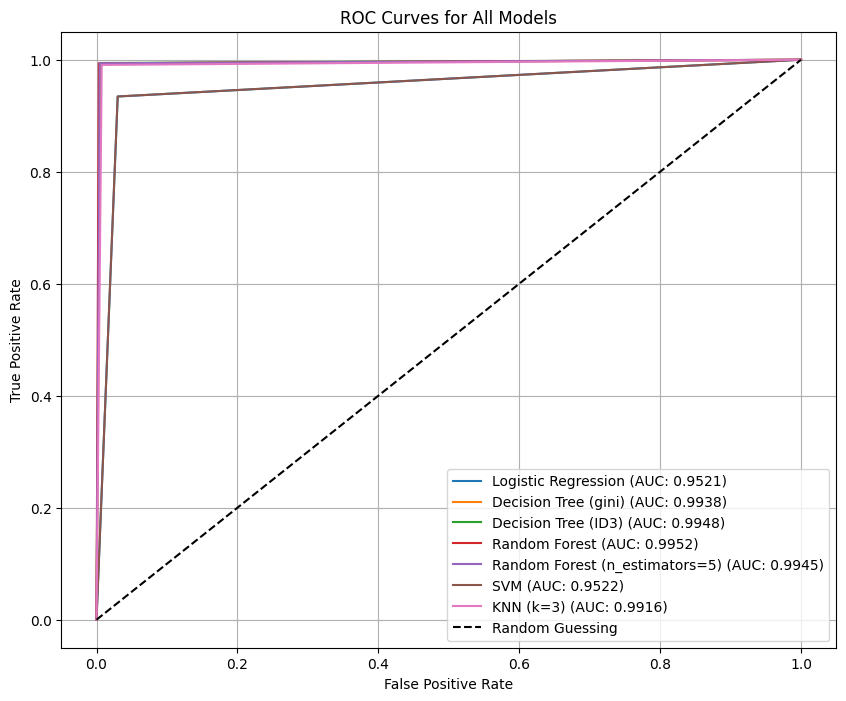

                               Training_Accuracy Testing_Accuracy  \
Logistic Regression                       0.9538           0.9528   
Decision Tree (gini)                      0.9991           0.9938   
Decision Tree (ID3)                       0.9991           0.9948   
Random Forest                             0.9991           0.9952   
Random Forest (n_estimators=5)            0.9986           0.9946   
SVM                                       0.9534           0.9528   
KNN (k=3)                                 0.9953           0.9917   

                               Balanced_Accuracy             ROC_AUC F1_Score  \
Logistic Regression                       0.9521  0.9520975705284341   0.9501   
Decision Tree (gini)                      0.9938  0.9938139779845885   0.9936   
Decision Tree (ID3)                       0.9948   0.994822837938791   0.9946   
Random Forest                             0.9952  0.9951619612677697   0.9950   
Random Forest (n_estimators=5)            

In [43]:
# Metrics and models configuration
evaluation_metrics = [
    "Training_Accuracy", "Testing_Accuracy", "Balanced_Accuracy", 
    "ROC_AUC", "F1_Score", "Recall", "Precision", 
    "Training_time", "Testing_time"
]

models = [
    "Logistic Regression", "Decision Tree (gini)", "Decision Tree (ID3)", 
    "Random Forest", "Random Forest (n_estimators=5)", "SVM", "KNN (k=3)"
]

df = pd.DataFrame(index=models, columns=evaluation_metrics)

# List of models to iterate
model_configs = [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Decision Tree (gini)", tree.DecisionTreeClassifier(criterion="gini")),
    ("Decision Tree (ID3)", tree.DecisionTreeClassifier(criterion="entropy")),
    ("Random Forest", RandomForestClassifier()),
    ("Random Forest (n_estimators=5)", RandomForestClassifier(n_estimators=5)),
    ("SVM", LinearSVC(C=1)),
    ("KNN (k=3)", KNeighborsClassifier(n_neighbors=3))
]

# Initialize a plot for ROC Curves
plt.figure(figsize=(10, 8))

# Train and evaluate each model
for model_name, model in model_configs:
    # Measure training time and train model
    start_train = time.time()
    model.fit(reduced_x_train, y_train)
    training_time = time.time() - start_train

    # Calculate Training Accuracy
    y_train_pred = model.predict(reduced_x_train)
    training_accuracy = accuracy_score(y_train, y_train_pred)

    # Measure testing time and predict on test set
    start_test = time.time()
    y_pred = model.predict(x_test)
    testing_time = time.time() - start_test

    # Calculate Testing Metrics
    testing_accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    try:
        roc_auc = roc_auc_score(y_test, y_pred)
    except ValueError:
        roc_auc = "N/A"  # Handle binary classification issue
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    # ROC Curve
    try:
        fpr, tpr, _ = roc_curve(y_test, y_pred)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC: {roc_auc:.4f})")
    except ValueError:
        print(f"ROC Curve could not be computed for {model_name}.")

    # Store results in DataFrame
    df.loc[model_name] = [
        f"{training_accuracy:.4f}", f"{testing_accuracy:.4f}", f"{balanced_accuracy:.4f}",
        f"{roc_auc}" if roc_auc != "N/A" else "N/A", f"{f1:.4f}",
        f"{recall:.4f}", f"{precision:.4f}", f"{training_time:.4f}s", f"{testing_time:.4f}s"
    ]

# Finalize the ROC Curve plot
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid()
plt.savefig("roc_curves_all_models.png")  # Save the plot
plt.show()

# Save metrics to Excel
df.to_excel("model_evaluation_metrics.xlsx")

# Print DataFrame
print(df)

In [47]:
print(set(reduced_x_train.columns) - set(x_test.columns))  # Features in x_train but not in x_test
print("=====================================================")
print(set(x_test.columns) - set(reduced_x_train.columns))  # Features in x_test but not in x_train

set()
set()


In [48]:
# Convert scaled training data to DataFrame
x_train_scaled_df = pd.DataFrame(reduced_x_train, columns=reduced_x_train.columns)
# Add the 'label' column to the DataFrame
x_train_scaled_df['label'] = y_train
# Save to CSV
x_train_scaled_df.to_csv(r'KDD_Train_Set2.csv', index=False)


# Convert scaled data back to DataFrame
x_test_scaled_df = pd.DataFrame(x_test, columns=x_test.columns)
# Add the 'label' column to the DataFrame
x_test_scaled_df['label'] = y_test
# Save to CSV
x_test_scaled_df.to_csv(r'KDD_Test_Set2.csv', index=False)

In [49]:
print(set(x_train_scaled_df.columns) - set(x_test_scaled_df.columns))  # Features in x_train but not in x_test
print("=====================================================")
print(set(x_test_scaled_df.columns) - set(x_train_scaled_df.columns))  # Features in x_test but not in x_train

set()
set()
